# Product Segmentation with K-Means Clustering

**Retail supermarket "SWALAYAN KEADILAN" - 2025 POS receipts**

This notebook builds an end-to-end, reproducible machine-learning pipeline that
segments products by their sales behaviour using K-Means clustering. The heavy
lifting lives in the `src/` package; this notebook orchestrates the phases and
presents the results.

## 1. Introduction

Retailers carry thousands of products with very different sales dynamics. Grouping
them into a small number of behavioural segments supports inventory planning,
shelf placement, promotions, and pricing. We use **unsupervised** learning
(K-Means) because there are no pre-existing labels; the goal is interpretability,
not prediction.

### Google Colab setup

Run this cell **first** when on Colab. It installs the dependencies, mounts
your Google Drive, and points the pipeline at your dataset. Edit the
`DATASET_DIR` line to match where you put the `struk penjualan 2025` folder on
your Drive. Running locally, the cell does nothing and the default `dataset/`
folder is used.

In [1]:
# --- Google Colab setup (no-op when running locally) ---
# On Colab this installs deps, mounts your Google Drive, changes the working
# directory to the project root, and points the pipeline at your dataset.
# EDIT PROJECT_ROOT to match where you uploaded this project on your Drive.
import os
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG")

if IN_COLAB:
    subprocess.run(
        ["pip", "install", "-q",
         "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn", "scipy", "loguru"],
        check=True,
    )

    from google.colab import drive
    drive.mount("/content/drive")

    # EDIT THIS to where you uploaded the project folder on your Drive:
    PROJECT_ROOT = "/content/drive/MyDrive/ml-k-means-clustering"

    # Change cwd to the project root so the path-walker in the next cell finds src/.
    # Without this, Path.cwd() returns /content/ and `from src import ...` fails.
    os.chdir(PROJECT_ROOT)

    os.environ["DATASET_DIR"] = f"{PROJECT_ROOT}/dataset/struk penjualan 2025"
    print("Colab setup done.")
    print("  cwd         =", os.getcwd())
    print("  DATASET_DIR =", os.environ["DATASET_DIR"])
else:
    print("Not on Colab; using the local repo and the dataset/ folder.")

Not on Colab; using the local repo and the dataset/ folder.


In [2]:
# Make the `src` package importable regardless of the working directory.
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

import pandas as pd
from IPython.display import Image, display

from src import config, parser, preprocessing, feature_engineering, visualization
from src.clustering import (
    scale_features, evaluate_k, select_optimal_k, fit_kmeans,
    build_cluster_profiles, run_segmented_clustering,
)

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
config.ensure_output_dirs()
print("Project root:", root)

Project root: e:\work\63.ml-k-means-clustering\repo


## 2. Problem Statement

Given raw Indonesian POS receipt logs, segment products into behavioural groups
using K-Means so the business can distinguish fast-moving, slow-moving, and
premium products and act on each group differently.

## 3. Dataset Description

* **Source:** `dataset/struk penjualan 2025/*.TXT` - 209 daily POS receipt logs.
* **Language / currency:** Indonesian; Indonesian Rupiah (IDR). Amounts use `.`
  as a thousands separator (`5.000` = 5000).
* **Receipt structure:** a transaction header line carries the datetime and
  receipt code; each product is a name line plus a quantity line; optional
  `Potongan` rows carry discounts; a trailing `**` marks excise (cukai) goods.

See `SPEC.md` for the full grammar and schema.

## 4. Data Parsing

Parse every receipt file into one row per product line.

In [3]:
transactions_raw = parser.parse_all()
print(f"{transactions_raw['source_file'].nunique()} files parsed")
print(f"{len(transactions_raw):,} product lines, "
      f"{transactions_raw['transaction_uid'].nunique():,} transactions, "
      f"{transactions_raw['product_code'].nunique():,} distinct products")
transactions_raw.head()

209 files parsed
52,067 product lines, 24,070 transactions, 1,735 distinct products


,source_file,station,transaction_id,transaction_uid,transaction_datetime,product_code,product_name,quantity,unit_price,line_total,line_discount,is_excise
0,02-20241227.TXT,02,O5BS/00001/1/AGG,02-20241227.TXT::O5BS/00001/1/AGG,2024-12-27 07:11:47,1320910,NARAYA KDLAI BTL320,1,6000,6000,0,False
1,02-20241227.TXT,02,O5BS/00002/1/AGG,02-20241227.TXT::O5BS/00002/1/AGG,2024-12-27 07:13:01,1492840,LARISST AIR MIN600ML,1,2000,2000,0,False
2,02-20241227.TXT,02,O5BS/00003/1/AGG,02-20241227.TXT::O5BS/00003/1/AGG,2024-12-27 07:13:15,0012690,AQUA AIR MINERAL1500,1,7000,7000,0,False
3,02-20241227.TXT,02,O5BS/00004/1/AGG,02-20241227.TXT::O5BS/00004/1/AGG,2024-12-27 07:15:21,0370270,WOODS PEP.EXT/STRG15,2,6700,13400,0,False
4,02-20241227.TXT,02,O5BS/00005/1/AGG,02-20241227.TXT::O5BS/00005/1/AGG,2024-12-27 07:16:50,1274950,LA ICE 16'S BKS,1,33800,33800,0,True


## 5. Data Cleaning

Remove duplicates, drop rows with missing/invalid fields, and validate
quantities and prices.

In [4]:
transactions, report = preprocessing.clean_transactions(transactions_raw)
print(report.summary())
transactions.to_csv(config.TRANSACTIONS_CSV, index=False)
transactions.describe(include="all").T

Cleaning: 52,067 -> 51,761 rows (dups -0, missing -0, bad qty -0, bad price -0, out-of-scope year -306)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
source_file,51761,208,02-20250224.TXT,1405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
station,51761,1,02,51761,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_id,51761,735,O5BS/00003/1/AGG,567,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_uid,51761,23891,02-20250908.TXT::O5BS/00075/1/AGG,86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_datetime,51761,NaN,NaN,NaN,2025-06-03 05:37:23.501574,2025-01-02 07:41:08,2025-02-06 11:05:57,2025-06-02 12:01:39,2025-09-12 14:24:33,2025-12-24 15:44:03,NaN
product_code,51761,1735,0357330,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,51761,1823,SAMPOERNA MILD 16'S,1200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,"51,761.00",NaN,NaN,NaN,1.81,1.00,1.00,1.00,1.00,552.00,6.93
unit_price,"51,761.00",NaN,NaN,NaN,"14,197.34",800.00,"5,900.00","9,700.00","20,000.00","149,000.00","11,928.95"
line_total,"51,761.00",NaN,NaN,NaN,"19,635.01",0.00,"6,700.00","11,500.00","22,500.00","2,213,400.00","35,788.03"


## 6. Exploratory Data Analysis

Dataset dimensions, top products, and the distribution / correlation of the
sales features. Figures are written to `reports/figures/`.

Products: 1735

Top 10 products by revenue:


,product_name,total_quantity_sold,total_revenue,transaction_count
1,SAMPOERNA MILD 16'S,1504,55547600,1200
28,234 ROKOK KRT 12/PCS,1438,29398200,832
90,LA FILTER LIGHT 16'S,662,23253900,212
26,LE MINERALE 330ML,9064,20338750,357
13,DJI SAM SOE S/PRM,859,19827700,768
25,AQUA AIR MINERAL 330,7455,18266700,280
210,GG FILTER MERAH 12'S,588,15788200,283
67,DJI SAM SOE MGNUM 12,556,15214700,363
851,MARLBORO BLS/BRST 20,289,14802300,101
70,LE MINERALE 600ML,3999,13378400,1025


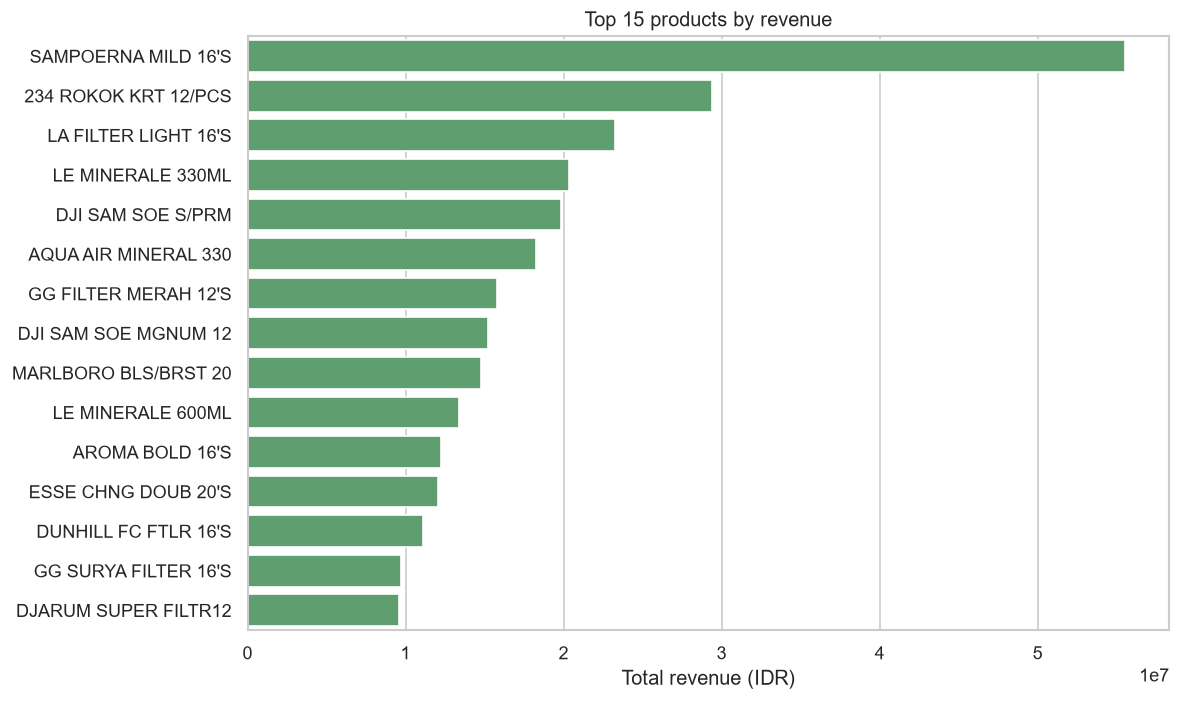

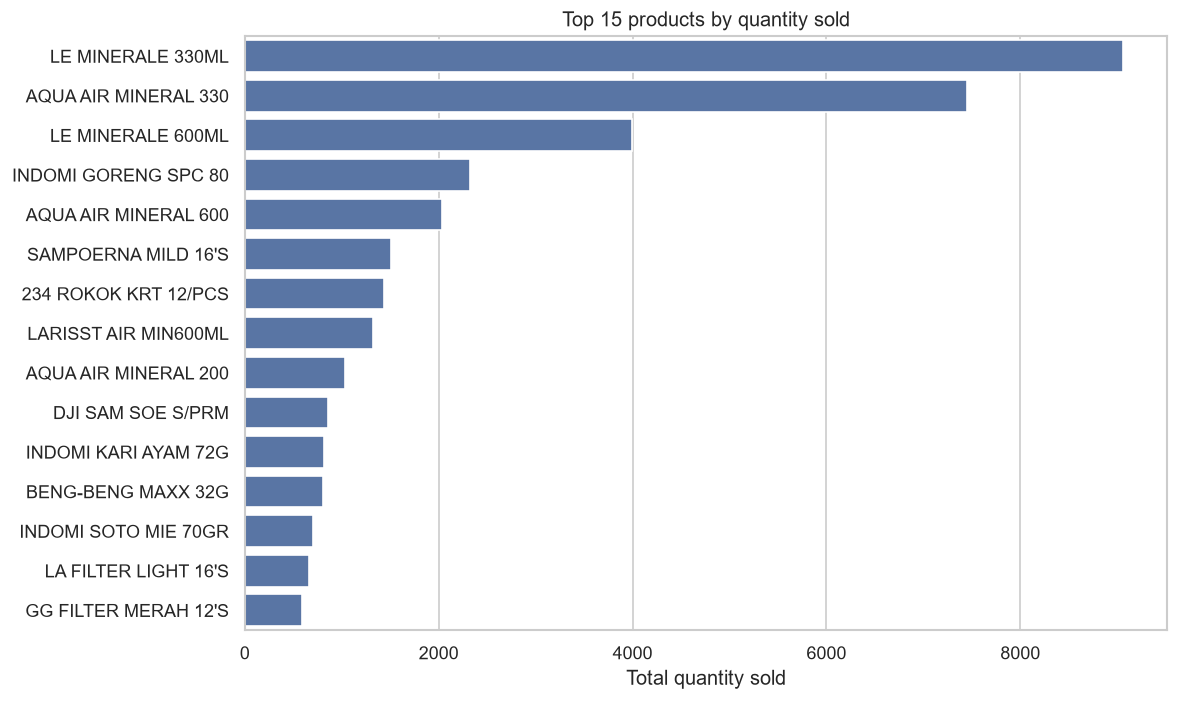

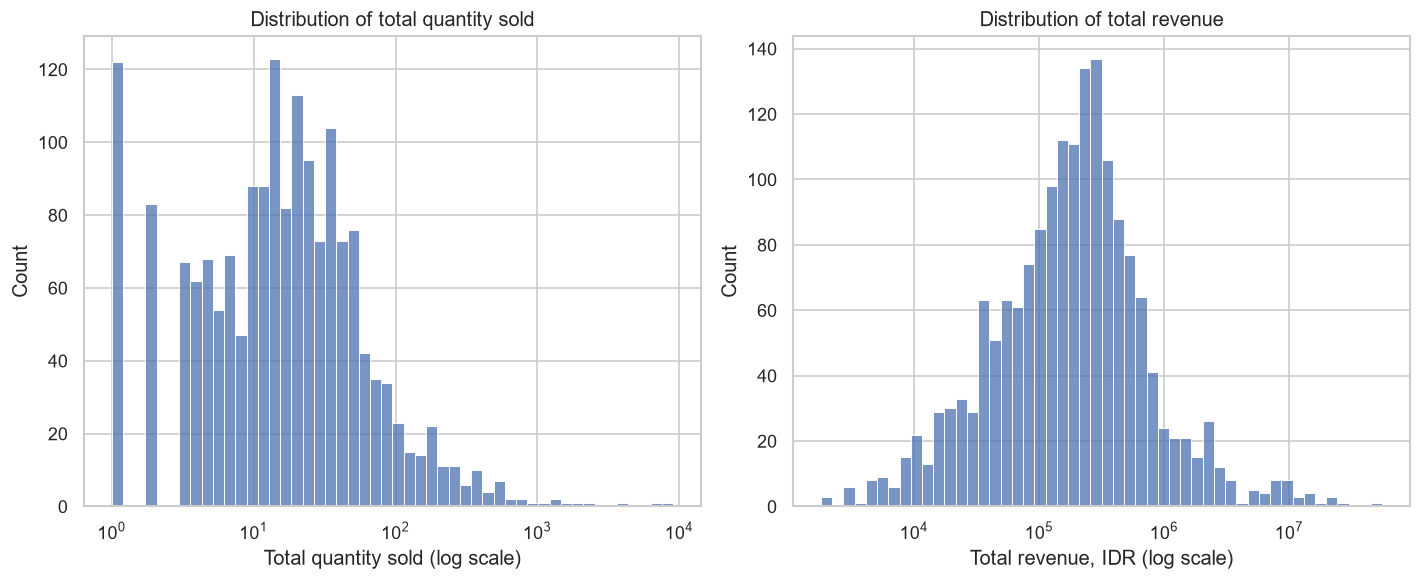

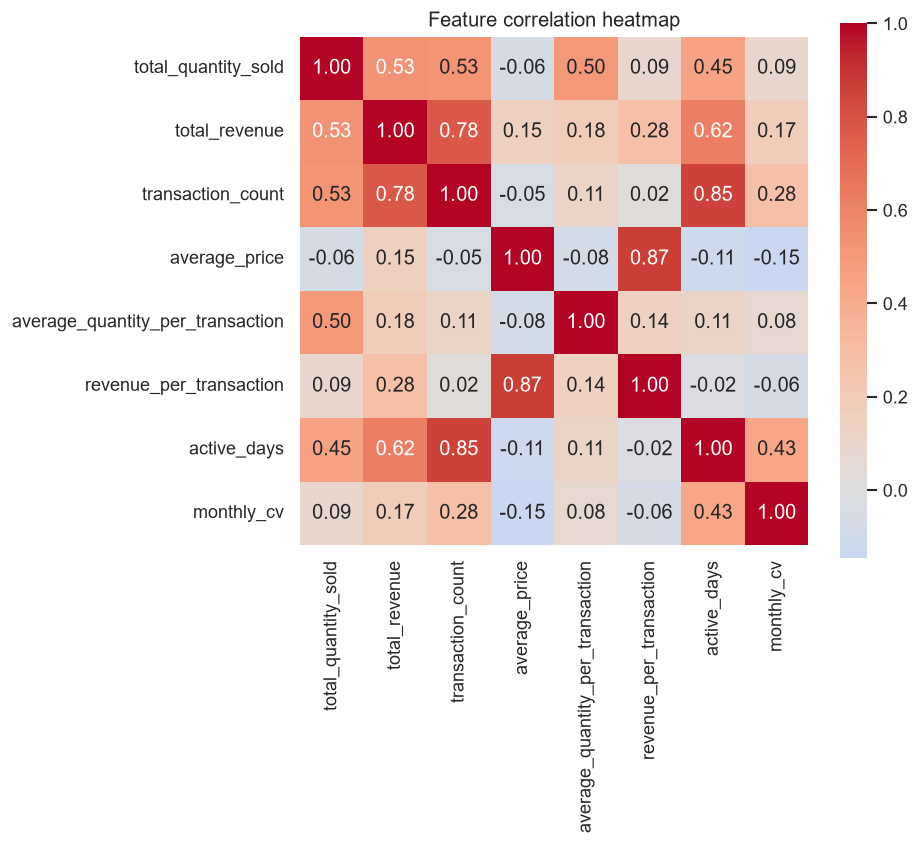

In [5]:
products_eda = feature_engineering.build_product_features(transactions)
print("Products:", len(products_eda))
print("\nTop 10 products by revenue:")
display(products_eda.nlargest(10, "total_revenue")[
    ["product_name", "total_quantity_sold", "total_revenue", "transaction_count"]
])
display(Image(filename=str(visualization.plot_top_products_by_revenue(products_eda))))
display(Image(filename=str(visualization.plot_top_products_by_quantity(products_eda))))
display(Image(filename=str(visualization.plot_distributions(products_eda))))
display(Image(filename=str(visualization.plot_correlation_heatmap(products_eda))))

## 7. Feature Engineering

Aggregate to one row per product and derive ratio features. Alongside the
volume/value features we engineer temporal features (`active_days`,
`monthly_cv`, `recency_days`, `weekend_ratio`) so the model can separate steady
sellers from spiky / seasonal products. The clustering feature set (numerical
only) is defined in `config.CLUSTERING_FEATURES`.

In [6]:
products = feature_engineering.build_product_features(transactions)
products.to_csv(config.PRODUCTS_CSV, index=False)
print("Clustering features:", config.CLUSTERING_FEATURES)
products.head()

Clustering features: [<ProdCol.TOTAL_QUANTITY_SOLD: 'total_quantity_sold'>, <ProdCol.TOTAL_REVENUE: 'total_revenue'>, <ProdCol.TRANSACTION_COUNT: 'transaction_count'>, <ProdCol.AVERAGE_PRICE: 'average_price'>, <ProdCol.AVERAGE_QUANTITY_PER_TRANSACTION: 'average_quantity_per_transaction'>, <ProdCol.REVENUE_PER_TRANSACTION: 'revenue_per_transaction'>, <ProdCol.ACTIVE_DAYS: 'active_days'>, <ProdCol.MONTHLY_CV: 'monthly_cv'>]


,product_code,product_name,total_quantity_sold,total_revenue,transaction_count,average_price,average_quantity_per_transaction,revenue_per_transaction,active_days,monthly_cv,discount_frequency,average_discount,sales_frequency_per_day,recency_days,weekend_ratio,is_excise
1,0357330,SAMPOERNA MILD 16'S,1504,55547600,1200,"36,933.24",1.25,"46,289.67",175,0.76,0.00,0.00,5.77,0,0.01,True
28,0357300,234 ROKOK KRT 12/PCS,1438,29398200,832,"20,443.81",1.73,"35,334.38",178,0.60,0.00,0.00,4.00,12,0.03,True
90,0357270,LA FILTER LIGHT 16'S,662,23253900,212,"35,126.74",3.12,"109,688.21",163,0.49,0.00,0.00,1.02,5,0.01,True
26,1304610,LE MINERALE 330ML,9064,20338750,357,"2,243.90",25.39,"56,971.29",152,0.47,0.91,"3,349.44",1.72,2,0.02,False
13,0714180,DJI SAM SOE S/PRM,859,19827700,768,"23,082.31",1.12,"25,817.32",184,0.47,0.00,0.00,3.69,5,0.03,True


## 8. Data Scaling

Retail features are strongly right-skewed, so we apply `log1p` and then
`StandardScaler`. The resulting matrix is standardised with no missing values.

Scaled matrix shape: (1735, 8)
All finite (no NaN/inf): True


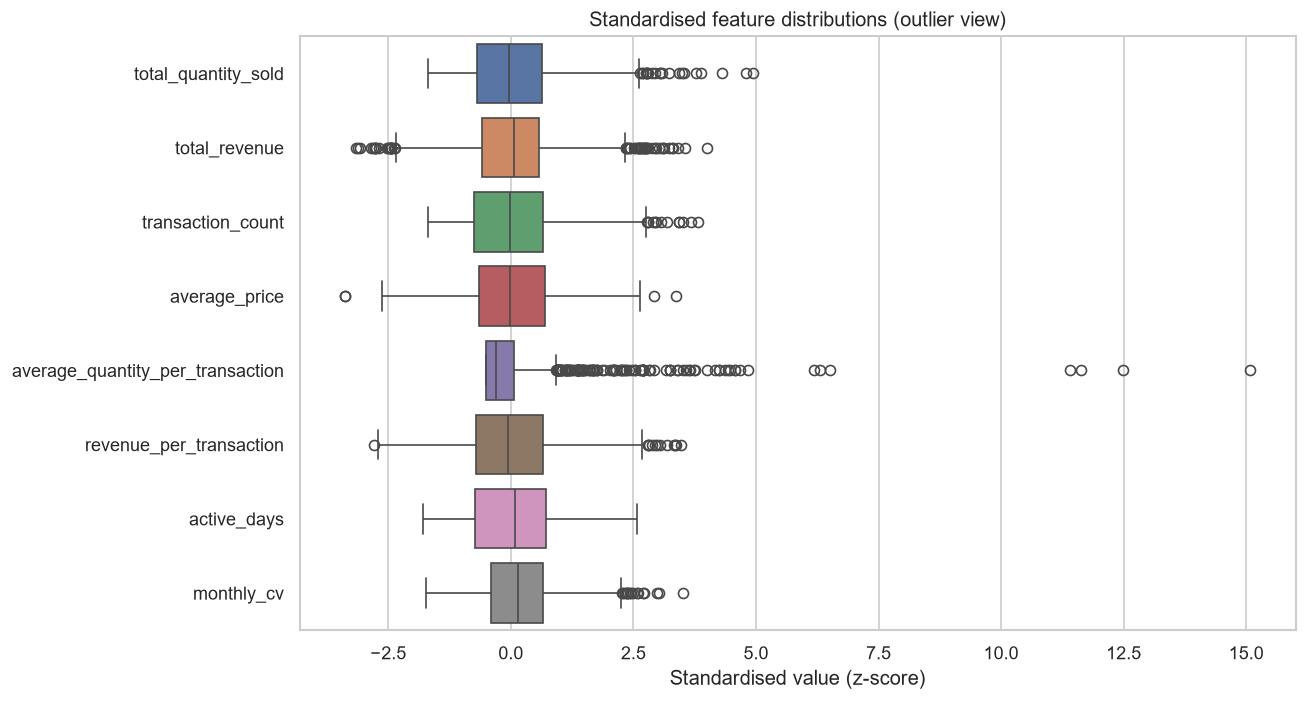

In [7]:
import numpy as np

scaled, scaler = scale_features(products)
print("Scaled matrix shape:", scaled.shape)
print("All finite (no NaN/inf):", bool(np.isfinite(scaled).all()))
display(Image(filename=str(visualization.plot_feature_boxplots(products))))

## 9. Elbow Method

Sweep k and inspect the within-cluster sum of squares (inertia).

,k,inertia,silhouette
0,2,"8,939.14",0.33
1,3,"7,478.47",0.25
2,4,"6,136.15",0.28
3,5,"5,338.51",0.28
4,6,"4,660.01",0.28
5,7,"4,174.42",0.28
6,8,"3,821.02",0.26
7,9,"3,518.02",0.26
8,10,"3,242.78",0.27


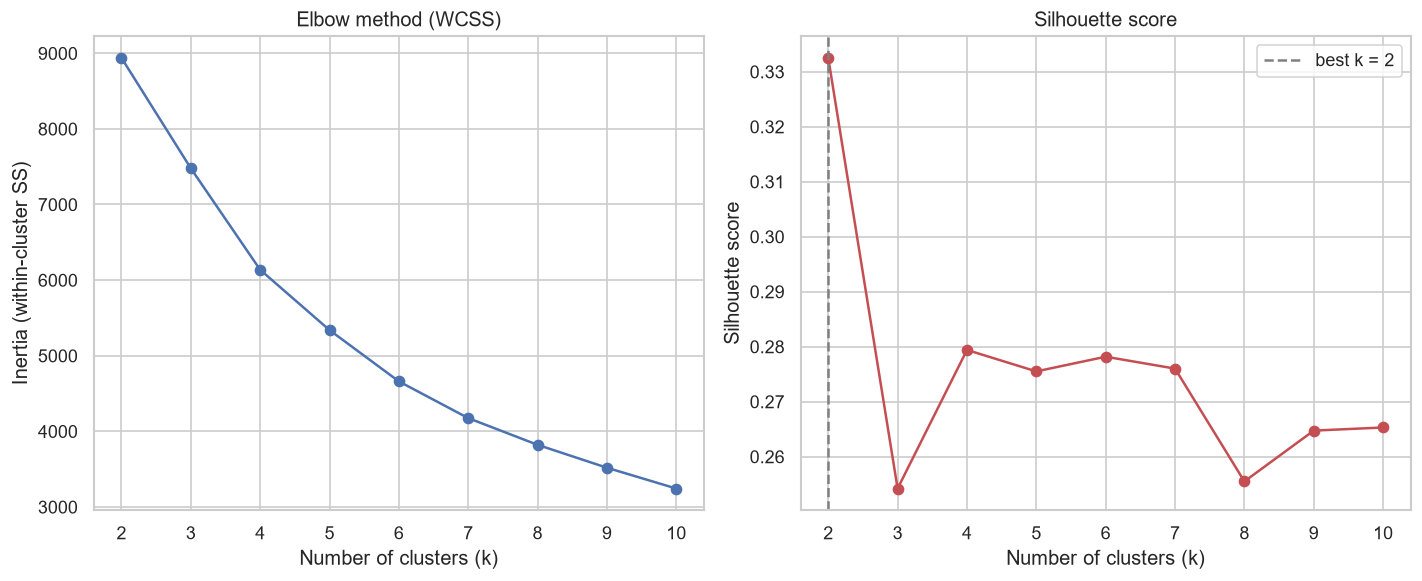

In [8]:
scores = evaluate_k(scaled)
display(scores)
display(Image(filename=str(visualization.plot_elbow_and_silhouette(scores))))

## 10. Silhouette Analysis

The silhouette score gives a single objective criterion for choosing k. We pick
the k with the highest score.

In [9]:
optimal_k = select_optimal_k(scores)
print(f"Optimal k = {optimal_k} "
      f"(silhouette = {scores['silhouette'].max():.3f})")

Optimal k = 2 (silhouette = 0.333)


## 11. K-Means Clustering

Fit the final K-Means model on the standardised features using the `k` chosen
above (`random_state=42`, `n_init=20`) and assign each product to a cluster.

In [10]:
model, labels = fit_kmeans(scaled, optimal_k)
products["cluster"] = labels
products.to_csv(config.CLUSTERED_CSV, index=False)
print(f"Fitted K-Means with k={optimal_k}; cluster sizes:")
products["cluster"].value_counts().sort_index()

Fitted K-Means with k=2; cluster sizes:


cluster
0    1010
1     725
Name: count, dtype: int64

## 12. Cluster Visualization

Project to 2-D with PCA and show cluster sizes.

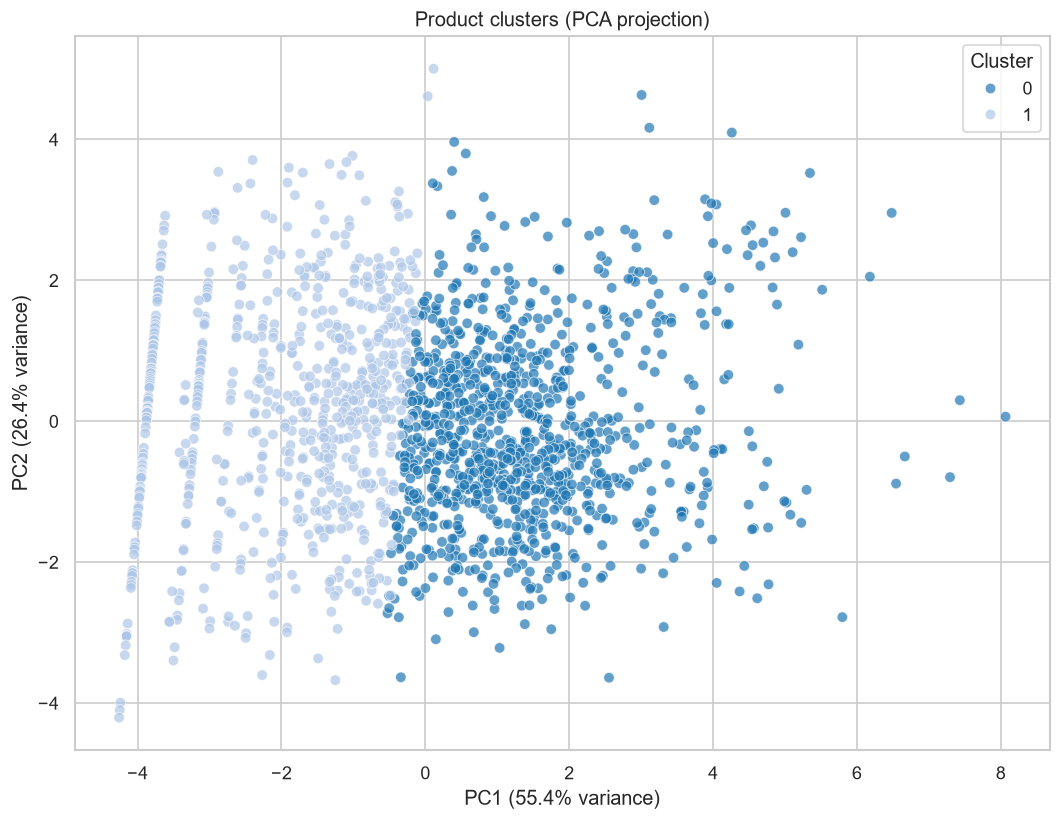

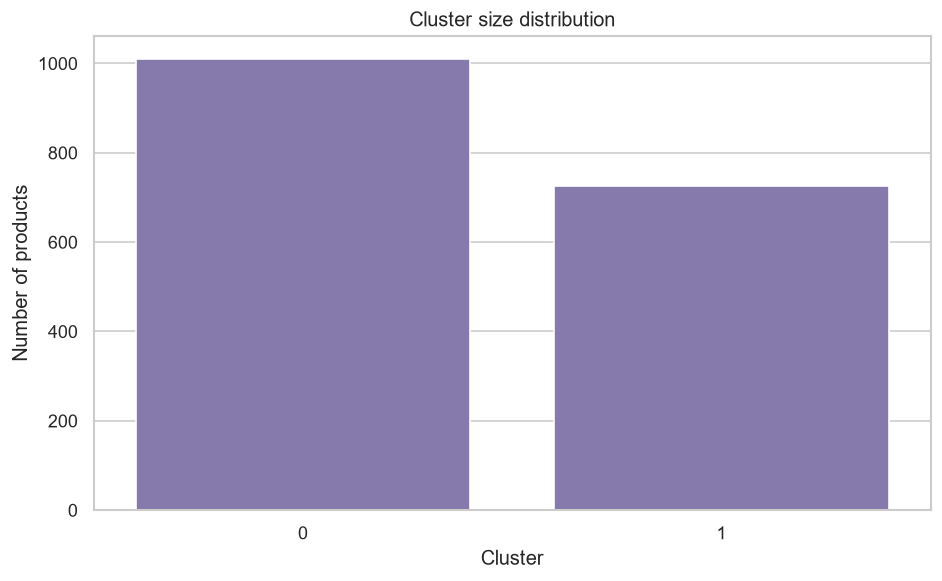

In [11]:
display(Image(filename=str(visualization.plot_pca_clusters(products))))
display(Image(filename=str(visualization.plot_cluster_sizes(products))))

## 13. Cluster Profiling

Average behaviour per cluster, used to label each segment.

In [12]:
profiles = build_cluster_profiles(products)
profiles.to_csv(config.CLUSTER_PROFILE_CSV, index=False)
profiles

,cluster,n_products,avg_quantity_sold,avg_revenue,avg_price,avg_transaction_count,avg_qty_per_txn,avg_revenue_per_txn,total_revenue,revenue_share
0,0,1010,88.63,"934,481.29","12,837.48",47.91,1.45,"16,457.77",943826100,0.93
1,1,725,5.39,"100,002.62","19,033.09",4.65,1.18,"21,837.56",72501900,0.07


### 13b. Refinement: clustering excise goods separately

Excise (cukai) goods such as cigarettes have extreme price and revenue and can
dominate the general segments. The pipeline supports clustering them in a
separate pass (`config.SEPARATE_EXCISE`). Below, each `segment_group` keeps its
own silhouette-selected k, and the profile carries the group label.

In [13]:
segmented = run_segmented_clustering(products.drop(columns="cluster"))
print(f"Total clusters across groups: {segmented.optimal_k}")
segmented.profiles

Total clusters across groups: 12


,cluster,n_products,avg_quantity_sold,avg_revenue,avg_price,avg_transaction_count,avg_qty_per_txn,avg_revenue_per_txn,total_revenue,revenue_share,segment_group
1,1,971,77.20,"528,892.02","11,331.71",39.42,1.45,"14,197.41",513554150,0.51,general
8,8,8,757.62,"19,821,862.50","25,281.99",568.00,1.34,"33,763.91",158574900,0.16,excise
2,2,12,191.25,"7,371,175.00","39,614.60",169.42,1.13,"45,033.45",88454100,0.09,excise
11,11,7,443.86,"11,345,085.71","24,338.11",168.57,2.68,"65,125.27",79415600,0.08,excise
0,0,674,5.00,"93,254.53","19,033.85",4.33,1.17,"21,847.61",62853550,0.06,general
4,4,20,52.30,"1,698,465.00","32,393.70",45.40,1.14,"36,611.86",33969300,0.03,excise
7,7,12,127.58,"2,581,591.67","20,250.23",106.58,1.19,"23,652.83",30979100,0.03,excise
5,5,4,141.25,"6,960,775.00","48,322.54",48.00,3.02,"134,614.19",27843100,0.03,excise
6,6,4,39.50,"3,144,500.00","93,087.99",29.50,1.18,"108,653.21",12578000,0.01,excise
3,3,12,13.42,"460,833.33","34,824.21",12.00,1.15,"39,661.44",5530000,0.01,excise


## 14. Business Insights

Read the profile table above and label each cluster, for example:

* **Fast-moving staples** - high quantity, high transaction count, low price.
  Keep deep stock, place at eye level, avoid stock-outs.
* **Premium / high-ticket** - high revenue per transaction, higher price, lower
  volume. Protect margin, feature in bundles, targeted promotions.
* **Long-tail / slow-movers** - low volume and revenue. Review shelf space,
  consider clearance or delisting.
* **Excise (cukai) segment** - cigarettes and similar; clustered separately
  (`segment_group == "excise"`) so their high price/revenue does not distort the
  general segments. Manage for compliance and margin.

Concrete recommendations span inventory management, promotion strategy, shelf
placement, product bundling, and stock optimisation. The narrative version lives
in `reports/final_report.md`.

In [14]:
# Programmatic helper: rank clusters by total revenue for the write-up.
summary = profiles[["cluster", "n_products", "avg_quantity_sold",
                    "avg_revenue", "avg_price", "revenue_share"]]
summary

,cluster,n_products,avg_quantity_sold,avg_revenue,avg_price,revenue_share
0,0,1010,88.63,"934,481.29","12,837.48",0.93
1,1,725,5.39,"100,002.62","19,033.09",0.07


## 15. Conclusion

We parsed 209 raw POS receipt logs into a clean transaction table, engineered
product-level features, selected k via the elbow and silhouette methods, and
trained a reproducible K-Means model (`random_state=42`). The resulting segments
are interpretable and map directly to inventory, pricing, and promotion actions.

Re-run the whole pipeline headlessly with:

```
uv run python -m src.run_pipeline
```